In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
RandomForestClassifier,
ExtraTreesClassifier,
GradientBoostingClassifier
)
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import(
accuracy_score,
f1_score,
classification_report,
confusion_matrix,
)


In [53]:
DATA_PATH = Path("../data/processed/crop_recommendation_clean.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,n,p,k,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [54]:
target_col = "label"
X = df.drop(columns=[target_col])
y = df[target_col]

X.shape, y.shape

((2200, 7), (2200,))

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)
X_train.shape, X_test.shape

((1760, 7), (440, 7))

The dataset was split into training and test sets using stratified sampling. This preserves the equal class distribution across both sets.

In [56]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=5000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),
    "ExtraTrees": ExtraTreesClassifier(
        n_estimators=300,
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": CalibratedClassifierCV(SVC(random_state=42), ensemble=False),
}

In [57]:
pipelines = {}

for name, model in models.items():
    pipelines[name] = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", model)
        ])

A standard preprocessing pipeline was used for all models. Although tree-based models do not require feature scaling, using pipelines keeps preprocessing consistent and reduces the risk of data leakage.

In [58]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted"
}

cv_results = []

for name, pipeline in pipelines.items():
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results.append({
        "model": name,
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_accuracy_std": scores["test_accuracy"].std(),
        "cv_macro_f1_mean": scores["test_macro_f1"].mean(),
        "cv_macro_f1_std": scores["test_macro_f1"].std(),
        "cv_macro_weighted_f1_mean": scores["test_macro_f1"].mean(),
        "cv_macro_weighted_f1_std": scores["test_macro_f1"].std()
    })

cv_results_df = (
    pd.DataFrame(cv_results)
    .sort_values("cv_macro_f1_mean", ascending=False)
    .reset_index(drop=True)
)

cv_results_df

,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_macro_weighted_f1_mean,cv_macro_weighted_f1_std
0,Random Forest,0.993750,0.003313,0.993731,0.003194,0.993731,0.003194
1,ExtraTrees,0.992045,0.004175,0.991907,0.004324,0.991907,0.004324
2,Gradient Boosting,0.990341,0.001392,0.990217,0.001468,0.990217,0.001468
3,Decision Tree,0.985227,0.004545,0.984950,0.004767,0.984950,0.004767
4,SVM,0.984659,0.006120,0.984537,0.006045,0.984537,0.006045
5,KNN,0.975000,0.005509,0.974969,0.005479,0.974969,0.005479
6,Logistic Regression,0.969886,0.004252,0.969647,0.004656,0.969647,0.004656


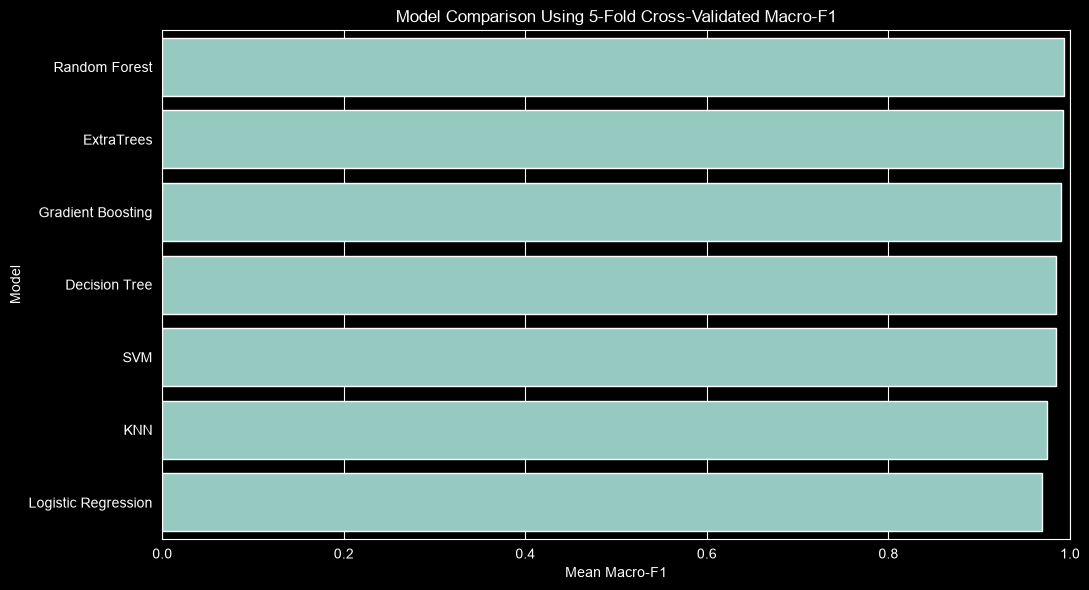

In [59]:
plt.figure(figsize=(11, 6))
sns.barplot(
    data=cv_results_df,
    x="cv_macro_f1_mean",
    y="model"
)
plt.title("Model Comparison Using 5-Fold Cross-Validated Macro-F1")
plt.xlabel("Mean Macro-F1")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

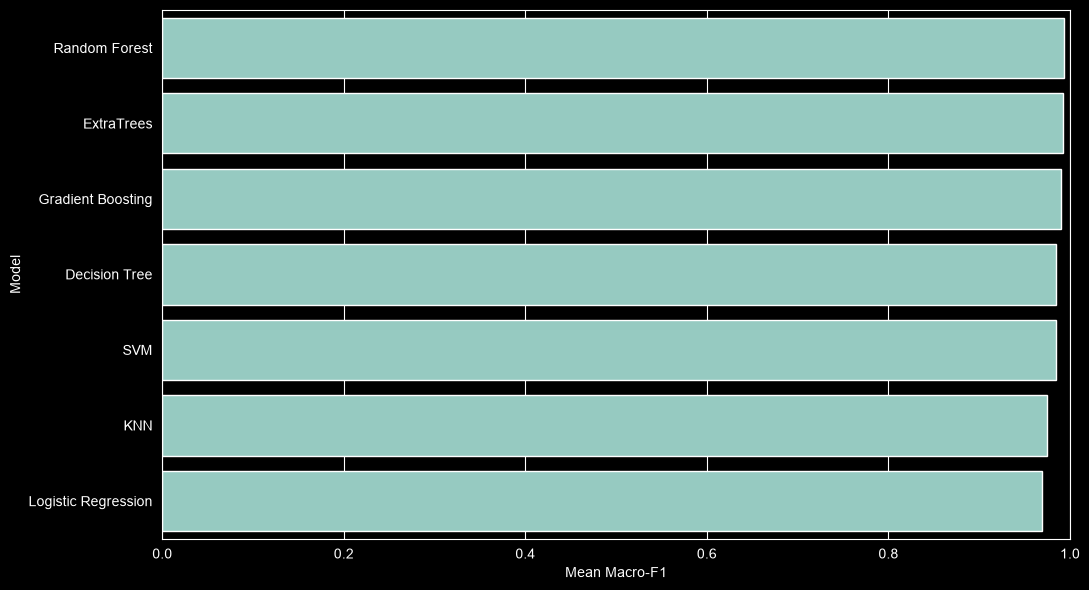

In [60]:
plt.figure(figsize=(11, 6))
sns.barplot(
    data=cv_results_df,
    x="cv_macro_f1_mean",
    y="model"
)
plt.xlabel("Mean Macro-F1")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.tight_layout()
plt.savefig("../reports/figures/model_comparison_cv_macro_f1.png", dpi=300)
plt.show()

In [61]:
test_results = []

for name, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    test_results.append({
        "model": name,
        "test_accuracy": accuracy_score(y_test, y_pred ),
        "test_macro_f1": f1_score(y_test, y_pred, average="macro"),
        "test_weighted_f1": f1_score(y_test, y_pred, average="weighted")
    })

test_result_df = (
    pd.DataFrame(test_results)
    .sort_values("test_macro_f1", ascending=False)
    .reset_index(drop=True)
)

test_result_df

,model,test_accuracy,test_macro_f1,test_weighted_f1
0,Random Forest,0.993182,0.992637,0.993175
1,Decision Tree,0.986364,0.986417,0.986315
2,ExtraTrees,0.986364,0.984977,0.986516
3,Gradient Boosting,0.981818,0.981869,0.981851
4,SVM,0.968182,0.966552,0.968027
5,Logistic Regression,0.963636,0.963559,0.963512
6,KNN,0.956818,0.954614,0.956749


In [62]:
combined_results = cv_results_df.merge(
    test_result_df,
    on="model",
    how="left"
)

combined_results

,model,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_macro_weighted_f1_mean,cv_macro_weighted_f1_std,test_accuracy,test_macro_f1,test_weighted_f1
0,Random Forest,0.993750,0.003313,0.993731,0.003194,0.993731,0.003194,0.993182,0.992637,0.993175
1,ExtraTrees,0.992045,0.004175,0.991907,0.004324,0.991907,0.004324,0.986364,0.984977,0.986516
2,Gradient Boosting,0.990341,0.001392,0.990217,0.001468,0.990217,0.001468,0.981818,0.981869,0.981851
3,Decision Tree,0.985227,0.004545,0.984950,0.004767,0.984950,0.004767,0.986364,0.986417,0.986315
4,SVM,0.984659,0.006120,0.984537,0.006045,0.984537,0.006045,0.968182,0.966552,0.968027
5,KNN,0.975000,0.005509,0.974969,0.005479,0.974969,0.005479,0.956818,0.954614,0.956749
6,Logistic Regression,0.969886,0.004252,0.969647,0.004656,0.969647,0.004656,0.963636,0.963559,0.963512


In [63]:
combined_results.to_csv(
    "../reports/model_comparison.csv", index=False
)

In [64]:
best_model_name = combined_results.loc[0, "model"]
best_model_name

'Random Forest'

In [65]:
# Retrieve and train the best model
best_model = pipelines[best_model_name]

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)


In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
      papaya       1.00    

The classification report shows model performance for each crop class. This is important because a high overall accuracy could hide weak performance on specific crops. Per-class precision, recall, and F1-score help confirm whether the model performs consistently across all 22 crop categories.

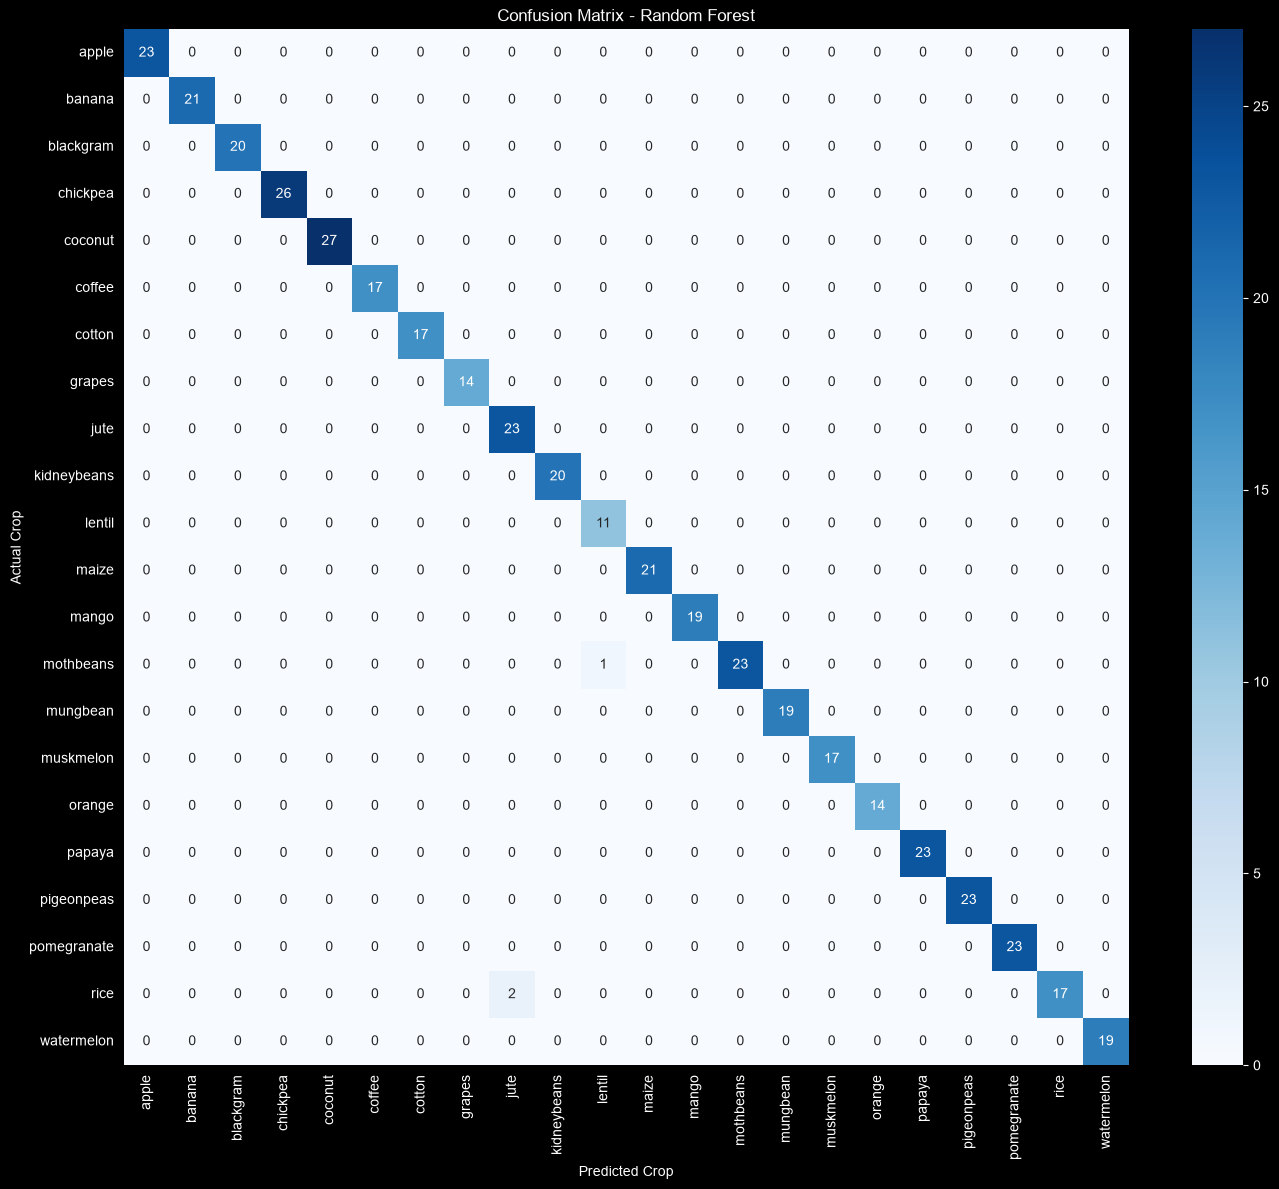

In [67]:
labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

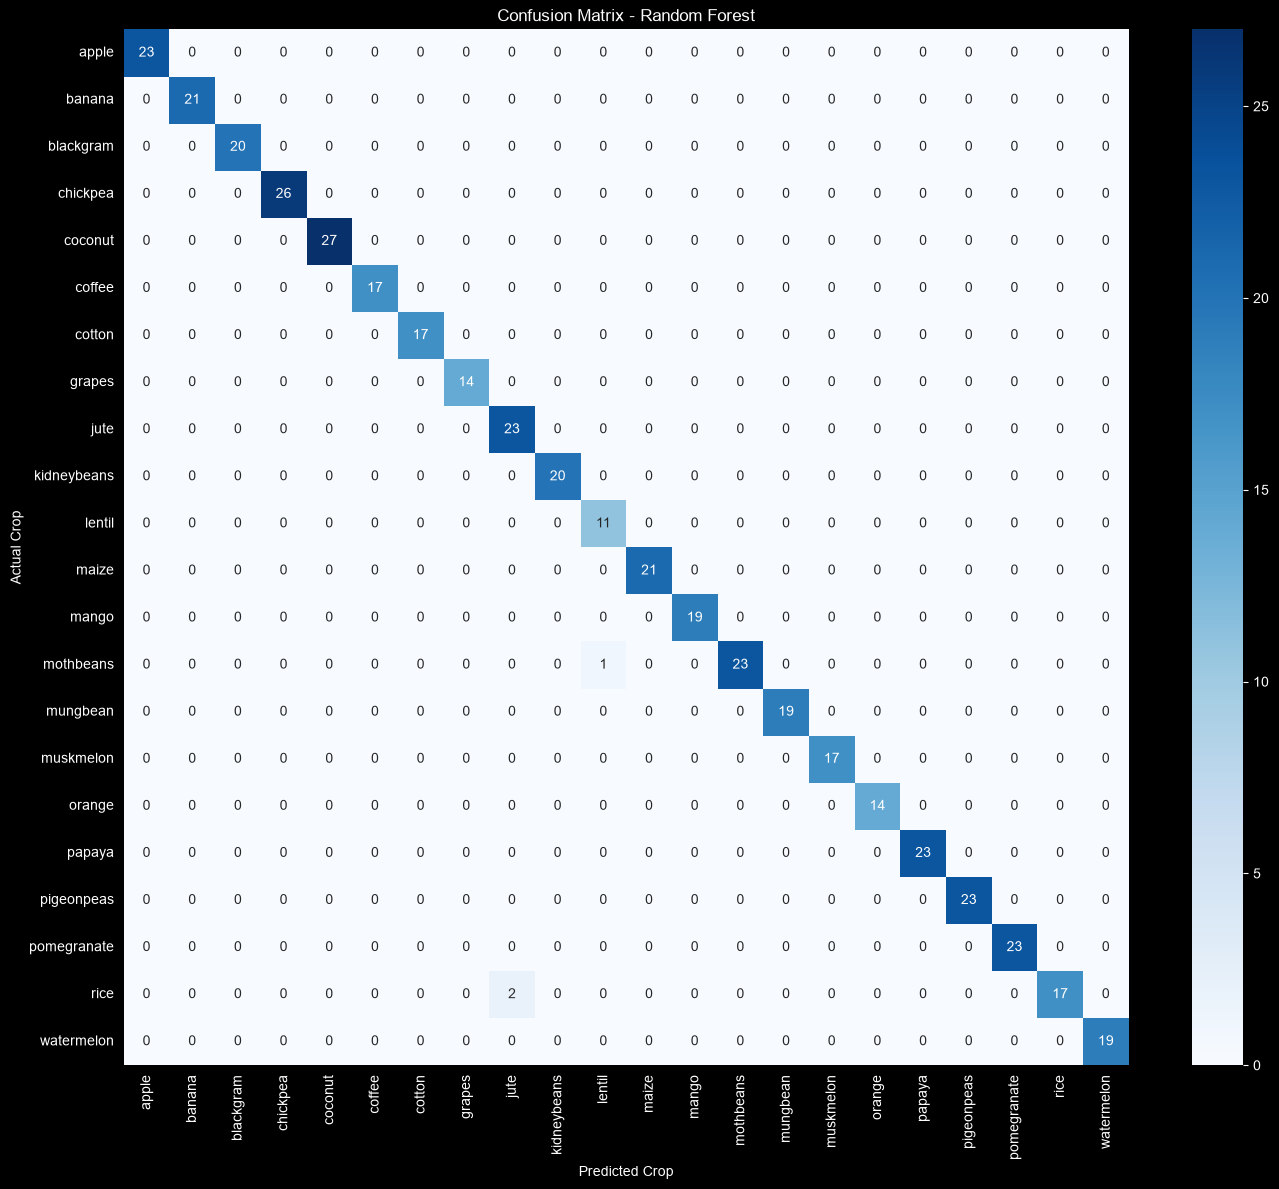

In [68]:
plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../reports/figures/confusion_matrix_best_model.png", dpi=300)
plt.show()

## Model Comparison Summary

Several machine learning models were trained and evaluated using the full set of soil and climate features.

The single-feature baseline showed that rainfall was the strongest individual predictor, but its macro-F1 score was low. When all features were combined, model performance improved dramatically.

Tree-based ensemble models such as Random Forest and Extra Trees performed especially well. These models are suitable for this dataset because they can capture non-linear relationships and feature interactions among soil nutrients, rainfall, humidity, temperature, and pH.

The best-performing model will be selected for further optimization, explainability analysis, and deployment.